In [5]:
import numpy as np
import pandas as pd
from geomeppy import IDF # download geomeppy library
import matplotlib.pyplot as plt

from pythermalcomfort.models.set_tmp import set_tmp # download pythermalcomfort library
import os

In [6]:
import warnings
warnings.filterwarnings("ignore", category=ResourceWarning)

In [7]:
# Set main inputs

# Path to EPW Annual Weather file corresponding to the year when the heatwave occured
epw_heatwave_path = '16289034113_2021.epw'

# Path to the IDF files of building under 2 scenarios (Natural Ventilation & Air Conditioning)
idf_path_nat_ventil = "20250605_363.idf"

# Path to the IDD file corresponding to the version of EnergyPlus that is used
idd_path = 'C:/EnergyPlusV23-1-0/Energy+.idd'

The Energyplus version used is 23-1-0


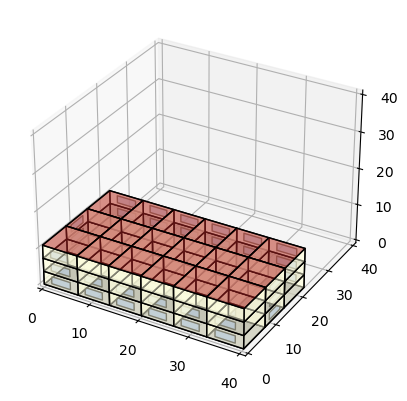

In [8]:
# Initialize values
IDF.setiddname(idd_path) # Input Data Dictionary (IDD) file that connects with the EnergyPlus version used

idf = IDF(idf_path_nat_ventil) # sets IDF file
IDF.translate_to_origin(idf) # moves close to (0,0,0) to avoid problems with large coordinates

idf.epw = epw_heatwave_path  # sets weather file

# Finds Energyplus version from the IDF file
idfversion = idf.idfobjects['VERSION'][0].Version_Identifier.split('.')
idfversion.extend([0] * (3 - len(idfversion)))
idfversionstr = '-'.join([str(item) for item in idfversion])

print("The Energyplus version used is", idfversionstr)

IDF.view_model(idf) 

In [9]:
# Adjust space list object according to the number of zones in the IDF file
idf.idfobjects['SPACELIST'].clear()
spaces = idf.idfobjects['SPACE']
    
space_fields = {}
for i, space in enumerate(spaces):
    space_fields[f"Space_{i+1}_Name"] = space.Name  

program_type = space.Space_Type              

idf.newidfobject(
    'SPACELIST', 
    Name = program_type, 
    **space_fields
    )    

idf.save()

In [10]:
# Calculate number of building zones
number_zones = len(idf.idfobjects["ZONE"])
print('The number of zones in the building is', number_zones)

# Create a default dataframe to store SET results for all zones
set_zone_names = []

for zone in idf.idfobjects["ZONE"]:
    set_zone_name = zone.Name.upper() + ':Zone Standard Effective Temperature [C](Hourly)'
    set_zone_names.append(set_zone_name)

df_set_hours = pd.DataFrame(columns=set_zone_names)

The number of zones in the building is 54


In [11]:
# Add only necessary output variables
idf.idfobjects['OUTPUT:VARIABLE'].clear()

idf.newidfobject("OUTPUT:VARIABLE", 
                     Variable_Name="Zone Mean Radiant Temperature", 
                     Reporting_Frequency="Hourly")

idf.newidfobject("OUTPUT:VARIABLE", 
                     Variable_Name="Zone Mean Air Temperature", 
                     Reporting_Frequency="Hourly")

idf.newidfobject("OUTPUT:VARIABLE", 
                     Variable_Name="Zone Air Relative Humidity", 
                     Reporting_Frequency="Hourly")


OUTPUT:VARIABLE,
    *,                        !- Key Value
    Zone Air Relative Humidity,    !- Variable Name
    Hourly;                   !- Reporting Frequency

In [12]:
# Makes options for Energyplus simulation
def make_eplaunch_options(idf):

    idfversion = idf.idfobjects['VERSION'][0].Version_Identifier.split('.')
    idfversion.extend([0] * (3 - len(idfversion)))
    idfversionstr = '-'.join([str(item) for item in idfversion])
    fname = idf.idfname

    options = {
        'ep_version':idfversionstr, # runIDFs needs the version number
        'output_prefix':os.path.basename(fname).split('.')[0],
        'output_suffix':'C',
        'output_directory':os.path.dirname(fname)+'/Outputs',
        'readvars':True,
        'expandobjects':True
        }
    return options

In [13]:
# Run Energyplus simulation
theoptions = make_eplaunch_options(idf)
idf.save()

idf.run(**theoptions)


C:\EnergyPlusV23-1-0\energyplus.exe --weather c:\Users\amkoniari\OneDrive - Delft University of Technology\Phd\A2_MultiCare\WP6\uploaded in github\Uploaded in github\16289034113_2021.epw --output-directory c:\Outputs --idd C:\EnergyPlusV23-1-0\Energy+.idd --expandobjects --readvars --output-prefix 20250605_363 --output-suffix C c:\Users\amkoniari\OneDrive - Delft University of Technology\Phd\A2_MultiCare\WP6\uploaded in github\Uploaded in github\20250605_363_7b70e9.idf



In [14]:
# Read results from the EnergyPlus simulation
results = pd.read_csv(f"C:/Users/amkoniari/OneDrive - Delft University of Technology/Phd/A2_MultiCare/WP6/uploaded in github/Uploaded in github/Outputs/{idf_path_nat_ventil[:-4]}.csv")

In [15]:
# Calculate SET values for each zone in the building
results.columns = results.columns.str.strip() # Remove any leading/trailing whitespace from column names to avoid errors
zone_names = []

for zone in idf.idfobjects["ZONE"]:

    mean_rad_temp = results[zone.Name.upper() + ':Zone Mean Radiant Temperature [C](Hourly)']
    mean_air_temp = results[zone.Name.upper() + ':Zone Mean Air Temperature [C](Hourly)']
    rel_humid = results[zone.Name.upper() + ':Zone Air Relative Humidity [%](Hourly)']

    set_temps = set_tmp(tdb=mean_air_temp, tr=mean_rad_temp, v=0.1, rh=rel_humid, met=1.1, clo=0.7, wme=0, 
                        body_surface_area=1.8258, p_atm=101325, position='sitting', 
                        limit_inputs=True, round_output=True, calculate_ce=False)
    
    set_zone_name = zone.Name.upper() + ':Zone Standard Effective Temperature [C](Hourly)'
    zone_names.append(zone.Name)
    df_set_hours[set_zone_name] = set_temps['set']

df_set_hours_filt = df_set_hours[[col for col in df_set_hours.columns if 'REST' not in col]] # Removes the intermediate zones of the building that correspond to corridors/staircases
zone_names = [zone_name for zone_name in zone_names if 'rest' not in zone_name]

print('The number of zones that are evaluated in the building is', len(zone_names))

The number of zones that are evaluated in the building is 42


In [16]:
# Find hour indexes that correspond to Heatwave period and after Heatwave period

def calculate_hoys(start_month_HW, start_day_HW, end_month_HW, end_day_HW):

    month_days = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

    hoys_hw = range(sum([24*month_days[month] for month in range(start_month_HW-1)]) + (start_day_HW-1)*24, sum([24*month_days[month] for month in range(end_month_HW-1)]) + end_day_HW*24 )
    total_hoys = sum([24*month_days[month] for month in range(12)])
    hoys_afterhw = range(hoys_hw[len(hoys_hw)-1], total_hoys)

    return(hoys_hw, hoys_afterhw, total_hoys)


start_month_HW = 8
start_day_HW = 8
end_month_HW = 8 
end_day_HW = 15

(hoys_hw, hoys_afterhw, total_hoys) = calculate_hoys(start_month_HW, start_day_HW, end_month_HW, end_day_HW)

print('The hour indexes corresponding to the heatwave period are:', hoys_hw)
print('The hour indexes corresponding to the period after the heatwave and until the end of the year are:', hoys_afterhw)
print('The number of the total hour indexes for the whole year are', total_hoys)

The hour indexes corresponding to the heatwave period are: range(5256, 5448)
The hour indexes corresponding to the period after the heatwave and until the end of the year are: range(5447, 8760)
The number of the total hour indexes for the whole year are 8760


In [17]:
# Calculate the Unmet SET hours during the response phase (heatwave)

def calculate_unmet_SET_hours_response(set_hours, hoys_hw, zone_names):
    
    unmet_set_zone_total = []
    set_hours_hw = [set_hours.iloc[hoys_hw[i]] for i in range(len(hoys_hw))] # Find the SET hours that correspond to the heatwave hour indexes
    df_set_hw = pd.DataFrame(set_hours_hw)
    cum_unmet_set_zone = np.zeros(len(zone_names)) # Initiate the array for calculating the cumulative unmet SET per zone

    for i, zone_name in enumerate(zone_names):

        zone_name_set = zone_name.upper() + ':Zone Standard Effective Temperature [C](Hourly)' # Get the zone name

        # Find the SET hours that are above the critical limit (30 degrees according to LEED standard Critical SET)
        set_hours_hw_above_critical_zone = [df_set_hw[zone_name_set].iloc[i] for i in range(len(hoys_hw)) if df_set_hw[zone_name_set].iloc[i] >=30] 
        
        # Calculate the unmet SET hours per zone (SET hours above limit)
        unmet_set_zone = [set_hours_hw_above_critical_zone[i] - 30 for i in range(len(set_hours_hw_above_critical_zone)) if set_hours_hw_above_critical_zone[i] - 30 != 30]
        unmet_set_zone_total.append(unmet_set_zone)

        # Find the cumulative unmet SET hours of the zone
        cum_unmet_set_zone[i] = sum(unmet_set_zone)

    # Calculate the worst cumulative SET and which is the zone with the worst cumulative SET
    worst_set_zone = np.argmax(cum_unmet_set_zone)
    worst_set = cum_unmet_set_zone[worst_set_zone]

    return(cum_unmet_set_zone, worst_set, worst_set_zone, unmet_set_zone_total)

# Calculate indicators for Natural Ventilation scenario
(cum_unmet_set_zone_NV, worst_set_NV, worst_set_zone_NV, unmet_set_zone_total) = calculate_unmet_SET_hours_response(df_set_hours_filt, hoys_hw, zone_names)
print('The cumulative unmet SET hours per zone in the Natural Ventilation scenario are:', cum_unmet_set_zone_NV)
print('The worst number of unmet SET hours per zone in the Natural Ventilation scenario is:', worst_set_NV)
print('The zone with the worst number of unmet SET hours in the Natural Ventilation scenario is:', zone_names[worst_set_zone_NV])

The cumulative unmet SET hours per zone in the Natural Ventilation scenario are: [268.4 272.2 345.2 348.7 116.6 118.4 183.8 185.7 183.9 109.  108.3 108.4
 109.1 175.2 174.4 174.5 175.5 173.  377.5 283.1 290.6 290.7 283.5 361.
 367.7 367.7 361.5 350.  298.6 301.9 368.8 372.1 397.7 310.6 314.3 314.5
 310.9 380.7 385.  385.1 381.1 371.3]
The worst number of unmet SET hours per zone in the Natural Ventilation scenario is: 397.70000000000016
The zone with the worst number of unmet SET hours in the Natural Ventilation scenario is: Flr1_Top_parameter_east_73f52d8a


In [18]:
df_set_hours_hw = df_set_hours_filt.iloc[hoys_hw]
df_set_hours_hw

,FLR1_CORNER_NORTH_1_7C108810:Zone Standard Effective Temperature [C](Hourly),FLR1_CORNER_NORTH_2_E94BCDF2:Zone Standard Effective Temperature [C](Hourly),FLR1_CORNER_SOUTH_1_9EEEEA95:Zone Standard Effective Temperature [C](Hourly),FLR1_CORNER_SOUTH_2_CE385D3D:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_CORNER_NORTH_1_7C108810:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_CORNER_NORTH_2_E94BCDF2:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_CORNER_SOUTH_1_9EEEEA95:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_CORNER_SOUTH_2_CE385D3D:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_PARAMETER_EAST_73F52D8A:Zone Standard Effective Temperature [C](Hourly),FLR1_GROUND_PARAMETER_NORTH_1_BD09306E:Zone Standard Effective Temperature [C](Hourly),...,FLR1_TOP_PARAMETER_EAST_73F52D8A:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_NORTH_1_BD09306E:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_NORTH_2_C181BAFF:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_NORTH_3_B2002846:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_NORTH_4_BB6081A6:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_SOUTH_1_FE9ED705:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_SOUTH_2_DA29AD93:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_SOUTH_3_2D783D8C:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_SOUTH_4_47DABC56:Zone Standard Effective Temperature [C](Hourly),FLR1_TOP_PARAMETER_WEST_EF66770D:Zone Standard Effective Temperature [C](Hourly)
5256,27.7,27.7,27.9,27.9,27.1,27.1,27.5,27.5,27.4,27.0,...,28.2,28.1,28.1,28.1,28.1,28.3,28.3,28.3,28.3,28.3
5257,27.3,27.2,27.5,27.5,26.7,26.7,27.1,27.1,27.0,26.7,...,27.7,27.6,27.7,27.7,27.6,27.8,27.8,27.8,27.8,27.8
5258,27.0,27.0,27.3,27.3,26.6,26.6,26.9,26.9,26.9,26.5,...,27.5,27.4,27.4,27.4,27.4,27.6,27.6,27.6,27.6,27.6
5259,27.1,27.1,27.3,27.3,26.7,26.7,27.0,27.0,27.0,26.6,...,27.6,27.5,27.5,27.5,27.5,27.6,27.7,27.7,27.6,27.6
5260,27.3,27.3,27.5,27.5,26.8,26.8,27.2,27.2,27.1,26.8,...,27.8,27.6,27.7,27.7,27.6,27.8,27.8,27.8,27.8,27.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5443,31.7,31.7,32.0,32.0,30.8,30.8,31.2,31.2,31.1,30.7,...,32.2,32.0,32.0,32.0,32.0,32.2,32.3,32.3,32.2,32.3
5444,31.2,31.2,31.5,31.5,30.4,30.4,30.8,30.8,30.7,30.3,...,31.7,31.5,31.6,31.6,31.5,31.8,31.8,31.8,31.8,31.8
5445,31.1,31.1,31.4,31.4,30.4,30.4,30.8,30.8,30.7,30.3,...,31.6,31.5,31.5,31.5,31.5,31.7,31.7,31.7,31.7,31.7
5446,31.1,31.1,31.3,31.3,30.4,30.4,30.8,30.8,30.7,30.3,...,31.6,31.4,31.4,31.4,31.4,31.6,31.6,31.6,31.6,31.6


In [19]:
df_set_hours_hw = df_set_hours_hw.reset_index(drop=False)
df_set_hours_hw = df_set_hours_hw.rename(columns={'index': 'hoys'})

In [20]:
start_datetime = pd.Timestamp('2024-01-01 00:00:00')
df_set_hours_hw['DateTime'] = [start_datetime + pd.Timedelta(hours=h) for h in df_set_hours_hw['hoys']]

In [21]:
# Calculate unmet cumulative SET hours for the heatwave period
cols = [col for col in df_set_hours_hw.columns if col not in ['hoys', 'DateTime']]

df_unmet_set = df_set_hours_hw.copy()
df_unmet_set[cols] = (df_unmet_set[cols] - 30).clip(lower=0)

df_cumsum = df_unmet_set.copy()
df_cumsum[cols] = df_unmet_set[cols].cumsum()

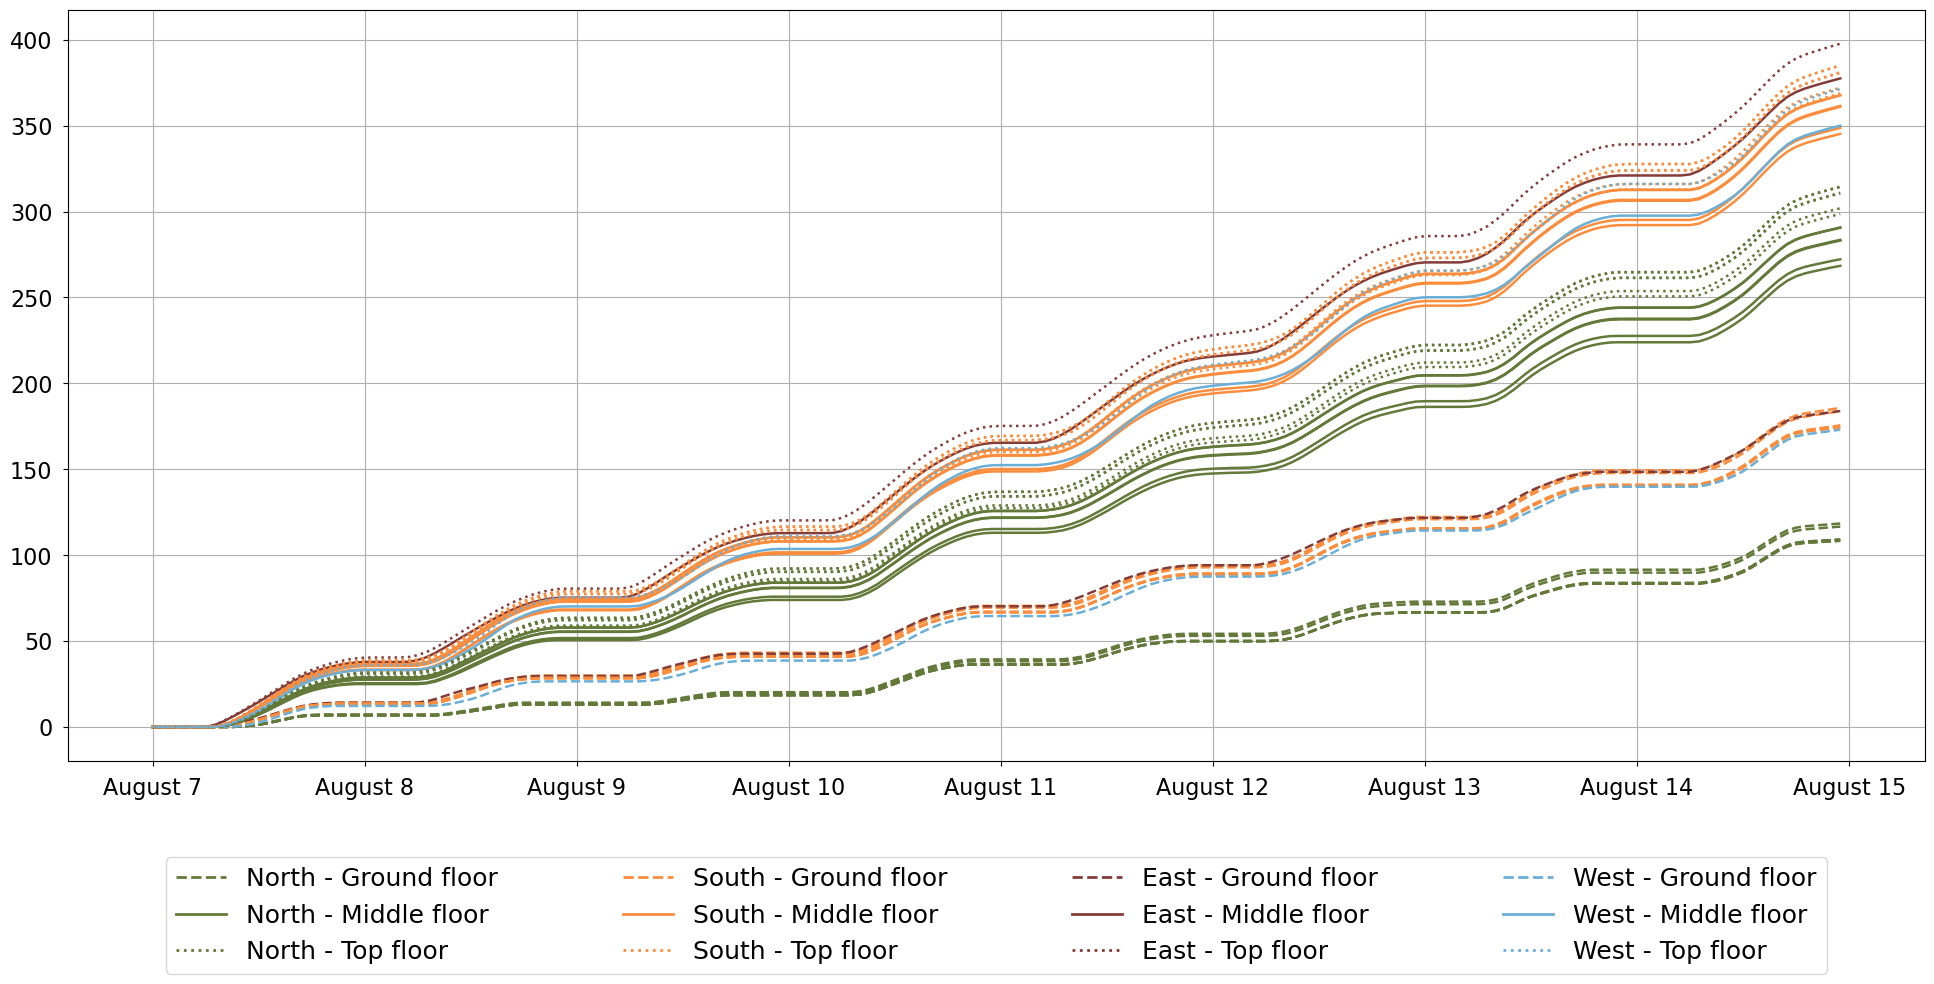

In [22]:
from matplotlib.lines import Line2D

plt.figure(figsize=(20, 10))

cols = [col for col in df_cumsum.columns if col not in ['hoys', 'DateTime']]

tab20b = plt.get_cmap('tab20b').colors
tab20c = plt.get_cmap('tab20c').colors

# Direction-specific colors
direction_colors = {
    'NORTH': tab20b[4], 
    'SOUTH': tab20c[5], 
    'EAST':  tab20b[12],
    'WEST':  tab20c[1], 
}

styles = {
    'Ground floor': '--', 
    'Middle floor': '-',   
    'Top floor': ':'    
}

for i, col in enumerate(cols):
    
    label_name = " ".join(col.split("_")[:-1])
    
    if 'GROUND' in label_name:
        linestyle = '--'  # Dashed for GROUND
    elif 'TOP' in label_name:
        linestyle = ':'   # Dotted for TOP
    else:
        linestyle = '-'   # Solid for others

    # Determine color based on direction
    color = None
    for direction, dir_color in direction_colors.items():
        if direction in label_name:
            color = dir_color
            break

    plt.plot(df_cumsum[col], label=label_name, color=color, linewidth=1.8, linestyle=linestyle) 

labels = ['August 7', 'August 8', 'August 9', 'August 10', 'August 11', 'August 12', 'August 13', 'August 14', 'August 15']
x = [0, 24, 48, 72, 96, 120, 144, 168, 192]  # Hour indices for the x-axis

plt.grid(True)
plt.xticks(ticks=x,labels=labels)
plt.tick_params(axis='both', labelsize=16, pad=8)

# Build custom legend handles
custom_handles = []
custom_labels = []

for direction, color in direction_colors.items():
    for style_name, linestyle in styles.items():
        handle = Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2)
        custom_handles.append(handle)
        custom_labels.append(f'{direction.title()} - {style_name}')

leg = plt.legend(custom_handles, custom_labels, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4, columnspacing=5, fontsize=18)
for line in leg.get_lines():
    line.set_linewidth(2)

plt.tight_layout()
plt.show()

In [23]:
# Calculate the SET indicators for the response phase

def calculate_SET_response_indicators(hoys_hw, cum_unmet_set_zone):
    
    reference_SET_response = 5*len(hoys_hw) # Reference SET hours to be used for the normalization (corresponds to a SET temperature of 35 degrees during the whole duration of the heatwave)
    norm_responses = []
    
    for zone_name, response_SET in zip(zone_names, cum_unmet_set_zone):
        
        normalized_response_SET = round(response_SET/reference_SET_response,2) # Normalized indicator
        norm_responses.append(normalized_response_SET)

        print('The normalized response SET indicator for zone', zone_name, 'is', normalized_response_SET)

    return(reference_SET_response, norm_responses)

# Calculate response SET indicators for the Natural Ventilation scenario
(reference_SET_response_NV, norm_responses) = calculate_SET_response_indicators(hoys_hw, cum_unmet_set_zone_NV)
print('The reference value for the normalization of the response SET indicators is', reference_SET_response_NV, 'SET hours')

The normalized response SET indicator for zone Flr1_corner_north_1_7c108810 is 0.28
The normalized response SET indicator for zone Flr1_corner_north_2_e94bcdf2 is 0.28
The normalized response SET indicator for zone Flr1_corner_south_1_9eeeea95 is 0.36
The normalized response SET indicator for zone Flr1_corner_south_2_ce385d3d is 0.36
The normalized response SET indicator for zone Flr1_Ground_corner_north_1_7c108810 is 0.12
The normalized response SET indicator for zone Flr1_Ground_corner_north_2_e94bcdf2 is 0.12
The normalized response SET indicator for zone Flr1_Ground_corner_south_1_9eeeea95 is 0.19
The normalized response SET indicator for zone Flr1_Ground_corner_south_2_ce385d3d is 0.19
The normalized response SET indicator for zone Flr1_Ground_parameter_east_73f52d8a is 0.19
The normalized response SET indicator for zone Flr1_Ground_parameter_north_1_bd09306e is 0.11
The normalized response SET indicator for zone Flr1_Ground_parameter_north_2_c181baff is 0.11
The normalized respon

In [24]:
# Calculate the hours of recovery time after the heatwave

def calculate_recovery_hours(set_hours, hoys_afterhw, zone_names):
    
    set_hours_after_hw = [set_hours.loc[hoys_afterhw[i]] for i in range(len(hoys_afterhw))] # Find the indexes of SET hours from the end of the heatwave until the end of the year
    df_set_after_hw = pd.DataFrame(set_hours_after_hw)
    recovery_hours = np.zeros(len(zone_names)) # Initiate the array for calculating the recovery hours per zone

    for i, zone_name in enumerate(zone_names):
        
        zone_name_set = zone_name.upper() + ':Zone Standard Effective Temperature [C](Hourly)' # Get the zone name from the zone_names list
        
        bool_unmet_set_hours_after_hw = [set_hour >=30 for set_hour in df_set_after_hw[zone_name_set].values] # Find which hours are above the critical SET limit
        
        if bool_unmet_set_hours_after_hw[0] == False: # If the first SET hour after the heatwave is below the critical limit, then we assume that there is no recovery time.
            print('No recovery time')
        else:
            unmet_set_hours_after_hw = [index for index, bool_set in enumerate(bool_unmet_set_hours_after_hw) if bool_set == True] # Find the indexes of SET hours that are above the critical limit
            
            for j in range(len(bool_unmet_set_hours_after_hw)):
                if j in unmet_set_hours_after_hw:
                    recovery_hours[i] = recovery_hours[i] + 1  # Calculate recovery hours per zone (how many consecutive hours above critical limit exist right after the heatwave)        
                else:
                    break
            print('The number of recovery hours for zone', zone_name, 'is', recovery_hours[i])
    
    return(recovery_hours)

# Calculate recovery hours - Natural Ventilation scenario
recovery_hours = calculate_recovery_hours(df_set_hours_filt, hoys_afterhw, zone_names)

The number of recovery hours for zone Flr1_corner_north_1_7c108810 is 25.0
The number of recovery hours for zone Flr1_corner_north_2_e94bcdf2 is 26.0
The number of recovery hours for zone Flr1_corner_south_1_9eeeea95 is 26.0
The number of recovery hours for zone Flr1_corner_south_2_ce385d3d is 26.0
The number of recovery hours for zone Flr1_Ground_corner_north_1_7c108810 is 25.0
The number of recovery hours for zone Flr1_Ground_corner_north_2_e94bcdf2 is 25.0
The number of recovery hours for zone Flr1_Ground_corner_south_1_9eeeea95 is 25.0
The number of recovery hours for zone Flr1_Ground_corner_south_2_ce385d3d is 25.0
The number of recovery hours for zone Flr1_Ground_parameter_east_73f52d8a is 25.0
The number of recovery hours for zone Flr1_Ground_parameter_north_1_bd09306e is 25.0
The number of recovery hours for zone Flr1_Ground_parameter_north_2_c181baff is 25.0
The number of recovery hours for zone Flr1_Ground_parameter_north_3_b2002846 is 25.0
The number of recovery hours for zo

In [25]:
# Calculate recovery phase indicators

def calculate_recovery_indicators(recovery_hours, zone_names):
    recovery_time_reference = 14*24 # Reference value for normalization (corresponds to a recovery period of 14 days)
    recovery_indices = []
    
    for zone_name, recovery_time in zip(zone_names, recovery_hours):
        
        recovery_ratio = recovery_time/recovery_time_reference # Normalized recovery indicator
        recovery_indices.append(recovery_ratio)
        print('The normalized recovery indicator for zone', zone_name, 'is', round(recovery_ratio, 2))

    return(recovery_time_reference, recovery_indices)

# Calculate recovery indicators - Natural Ventilation scenario
(recovery_time_reference, recovery_indices) = calculate_recovery_indicators(recovery_hours, zone_names)

The normalized recovery indicator for zone Flr1_corner_north_1_7c108810 is 0.07
The normalized recovery indicator for zone Flr1_corner_north_2_e94bcdf2 is 0.08
The normalized recovery indicator for zone Flr1_corner_south_1_9eeeea95 is 0.08
The normalized recovery indicator for zone Flr1_corner_south_2_ce385d3d is 0.08
The normalized recovery indicator for zone Flr1_Ground_corner_north_1_7c108810 is 0.07
The normalized recovery indicator for zone Flr1_Ground_corner_north_2_e94bcdf2 is 0.07
The normalized recovery indicator for zone Flr1_Ground_corner_south_1_9eeeea95 is 0.07
The normalized recovery indicator for zone Flr1_Ground_corner_south_2_ce385d3d is 0.07
The normalized recovery indicator for zone Flr1_Ground_parameter_east_73f52d8a is 0.07
The normalized recovery indicator for zone Flr1_Ground_parameter_north_1_bd09306e is 0.07
The normalized recovery indicator for zone Flr1_Ground_parameter_north_2_c181baff is 0.07
The normalized recovery indicator for zone Flr1_Ground_parameter_